# Sequence Recommender Intro

## Роль notebook

Этот notebook вводит sequence-aware постановку: порядок событий становится частью сигнала.
Здесь мы впервые явно думаем не только о том, что пользователь делал раньше, но и о том, какое действие было последним перед следующим событием.


## Почему Retailrocket

Для этой главы нужен датасет с естественной событийностью. `Retailrocket` подходит лучше, чем `MovieLens` и `Amazon Reviews`, потому что там есть e-commerce события `view`, `addtocart`, `transaction` и явный `timestamp`.

Это позволяет поставить задачу `next-item`: по прошлой последовательности событий пользователя предсказать следующий объект, с которым он взаимодействует.


## План

- один раз скачать `Retailrocket ecommerce dataset` в локальный `data/raw/retailrocket`;
- работать уже с локальными `events.csv`, `item_properties_part*.csv`, `category_tree.csv`;
- собрать компактный воспроизводимый срез событий;
- сделать `train / validation / test` по времени внутри пользователя;
- сравнить обычный `popularity baseline` с простой sequential baseline;
- объяснить, почему next-item постановка отличается от обычного top-K.


## Требования к окружению

Отдельный Kaggle token больше не нужен: helper проекта скачивает публичные CSV-файлы Retailrocket напрямую и сохраняет их локально.

Ожидаемая локальная директория после скачивания:

- `data/raw/retailrocket/events.csv`
- `data/raw/retailrocket/item_properties_part1.csv`
- `data/raw/retailrocket/item_properties_part2.csv`
- `data/raw/retailrocket/category_tree.csv`

Дальше notebook читает уже локальные файлы и не скачивает датасет повторно.


In [1]:
import os

os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


def find_project_root(start_path: Path) -> Path:
    for candidate in [start_path, *start_path.parents]:
        if (candidate / "src" / "recsys_basics").exists():
            return candidate
    raise FileNotFoundError("Не удалось найти корень проекта с папкой src/recsys_basics")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
plt.style.use("ggplot")

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"SRC_DIR: {SRC_DIR}")


PROJECT_ROOT: /Users/bobrsubr/PycharmProjects/_researches/recommender-systems-from-zero
SRC_DIR: /Users/bobrsubr/PycharmProjects/_researches/recommender-systems-from-zero/src


In [2]:
# Скачайте Retailrocket один раз. Ячейка reload'ит модуль,
# чтобы Jupyter не держал старую версию downloader после правок в src/.
# import importlib
# import recsys_basics.data as data_module
#
# data_module = importlib.reload(data_module)
# print(f"Retailrocket target dir: {data_module.get_retailrocket_data_dir()}")
#
# data_module.download_retailrocket_files()


Retailrocket target dir: /Users/bobrsubr/PycharmProjects/_researches/recommender-systems-from-zero/data/raw/retailrocket


PosixPath('/Users/bobrsubr/PycharmProjects/_researches/recommender-systems-from-zero/data/raw/retailrocket')

In [3]:
from recsys_basics.advanced.sequence_model import (
    LastItemTransitionRecommender,
    build_user_last_items,
)
from recsys_basics.basic.popularity import PopularityRecommender
from recsys_basics.data import (
    build_retailrocket_interactions,
    get_retailrocket_data_dir,
    load_retailrocket_frames,
)
from recsys_basics.metrics import evaluate_ranking_metrics
from recsys_basics.split import assert_no_user_time_leakage, leave_last_two_out_split

DATA_DIR = get_retailrocket_data_dir()
TOP_K = 10

frames = load_retailrocket_frames(DATA_DIR)
interactions_df = build_retailrocket_interactions(frames.events)

print(f"Events loaded: {len(interactions_df):,}")
print(f"Users: {interactions_df['user_id'].nunique():,}")
print(f"Items: {interactions_df['item_id'].nunique():,}")
display(interactions_df.head())


Events loaded: 2,756,101
Users: 1,407,580
Items: 235,061


,user_id,item_id,event,timestamp
0,693516,297662,addtocart,2015-05-03 03:00:04.384000+00:00
1,829044,60987,view,2015-05-03 03:00:11.289000+00:00
2,652699,252860,view,2015-05-03 03:00:13.048000+00:00
3,1125936,33661,view,2015-05-03 03:00:24.154000+00:00
4,693516,297662,view,2015-05-03 03:00:26.228000+00:00


In [4]:
event_summary = (
    interactions_df.groupby("event")
    .size()
    .rename("events")
    .reset_index()
    .sort_values("events", ascending=False)
)
event_summary["share"] = event_summary["events"] / event_summary["events"].sum()
display(event_summary)


,event,events,share
2,view,2664312,0.9667
0,addtocart,69332,0.0252
1,transaction,22457,0.0081


## Интерпретация распределения событий

Почти все события в Retailrocket — это `view`: около 96.7%. `addtocart` и `transaction` встречаются намного реже.

Это важно для чтения метрик: текущая next-item задача в основном проверяет, умеем ли мы предсказывать следующий просмотр товара. Это не то же самое, что предсказывать покупку. Для отдельной purchase-задачи нужно было бы менять target, веса событий или делать отдельную постановку.


In [5]:
def iterative_k_core(
    interactions: pd.DataFrame,
    min_user_events: int = 3,
    min_item_events: int = 3,
    max_rounds: int = 10,
) -> pd.DataFrame:
    current = interactions.copy()
    for _ in range(max_rounds):
        before_len = len(current)
        user_counts = current.groupby("user_id").size()
        item_counts = current.groupby("item_id").size()
        current = current[current["user_id"].isin(user_counts[user_counts >= min_user_events].index)]
        current = current[current["item_id"].isin(item_counts[item_counts >= min_item_events].index)]
        current = current.reset_index(drop=True)
        if len(current) == before_len:
            break
    return current


def make_compact_sequence_slice(
    interactions: pd.DataFrame,
    max_users: int = 3000,
    max_items: int = 5000,
    min_user_events: int = 3,
    min_item_events: int = 3,
) -> pd.DataFrame:
    working = interactions.sort_values(["timestamp", "user_id", "item_id"]).copy()
    working = iterative_k_core(
        working,
        min_user_events=min_user_events,
        min_item_events=min_item_events,
    )

    top_users = (
        working.groupby("user_id")
        .size()
        .sort_values(ascending=False)
        .head(max_users)
        .index
    )
    working = working[working["user_id"].isin(top_users)].copy()

    top_items = (
        working.groupby("item_id")
        .size()
        .sort_values(ascending=False)
        .head(max_items)
        .index
    )
    working = working[working["item_id"].isin(top_items)].copy()
    working = iterative_k_core(
        working,
        min_user_events=min_user_events,
        min_item_events=min_item_events,
    )
    return working.sort_values(["timestamp", "user_id", "item_id"]).reset_index(drop=True)


sequence_df = make_compact_sequence_slice(interactions_df)

slice_summary = pd.DataFrame(
    {
        "metric": [
            "events_after_slice",
            "users_after_slice",
            "items_after_slice",
            "first_timestamp",
            "last_timestamp",
        ],
        "value": [
            len(sequence_df),
            sequence_df["user_id"].nunique(),
            sequence_df["item_id"].nunique(),
            sequence_df["timestamp"].min(),
            sequence_df["timestamp"].max(),
        ],
    }
)

display(slice_summary)


,metric,value
0,events_after_slice,142881
1,users_after_slice,2880
2,items_after_slice,5000
3,first_timestamp,2015-05-03 03:12:21.433000+00:00
4,last_timestamp,2015-09-18 02:56:44.475000+00:00


## Интерпретация среза

После фильтрации остаётся компактный, но не игрушечный срез: 142,881 событий, 2,880 пользователей и 5,000 объектов.

Это компромисс для учебного notebook: данных достаточно, чтобы увидеть последовательный сигнал, но объём ещё позволяет быстро обучить baseline и посчитать метрики локально.


In [6]:
split_result = leave_last_two_out_split(sequence_df, min_user_interactions=3)
train_df = split_result.train.copy()
val_df = split_result.validation.copy()
test_df = split_result.test.copy()

assert_no_user_time_leakage(train_df, val_df)
assert_no_user_time_leakage(pd.concat([train_df, val_df], ignore_index=True), test_df)

train_item_ids = set(train_df["item_id"].unique().tolist())
val_new_item_share = float((~val_df["item_id"].isin(train_item_ids)).mean())
test_new_item_share = float((~test_df["item_id"].isin(train_item_ids)).mean())

split_summary = pd.DataFrame(
    {
        "metric": [
            "train_rows",
            "validation_rows",
            "test_rows",
            "train_users",
            "validation_users",
            "test_users",
            "train_items",
            "validation_items",
            "test_items",
            "validation_new_item_share_vs_train",
            "test_new_item_share_vs_train",
        ],
        "value": [
            len(train_df),
            len(val_df),
            len(test_df),
            train_df["user_id"].nunique(),
            val_df["user_id"].nunique(),
            test_df["user_id"].nunique(),
            train_df["item_id"].nunique(),
            val_df["item_id"].nunique(),
            test_df["item_id"].nunique(),
            val_new_item_share,
            test_new_item_share,
        ],
    }
)

display(split_summary)


,metric,value
0,train_rows,"137,121.0000"
1,validation_rows,"2,880.0000"
2,test_rows,"2,880.0000"
3,train_users,"2,880.0000"
4,validation_users,"2,880.0000"
5,test_users,"2,880.0000"
6,train_items,"5,000.0000"
7,validation_items,"2,181.0000"
8,test_items,"2,161.0000"
9,validation_new_item_share_vs_train,0.0000


## Интерпретация split

У каждого пользователя ровно одно validation-событие и одно test-событие, поэтому `validation_rows` и `test_rows` совпадают с числом пользователей.

`validation_new_item_share_vs_train = 0` и `test_new_item_share_vs_train = 0` означают, что все target items уже встречались в train-каталоге. Здесь мы проверяем sequence-ranking внутри известного каталога, а не cold-start для новых товаров.


Здесь `validation` и `test` снова не являются случайными процентами датасета. Для каждого пользователя мы берём предпоследнее событие как `validation`, последнее событие как `test`, а более раннюю историю оставляем в `train`.

Для sequence-aware постановки это особенно важно: если перемешать события случайно, модель легко увидит будущее поведение пользователя в train.


## Почему здесь не фильтруем seen items

В предыдущих top-K главах мы часто убирали уже просмотренные объекты из рекомендаций. В next-item сценарии это не всегда корректно: пользователь может снова посмотреть тот же товар, вернуться к нему перед покупкой или повторить действие.

Поэтому в этом notebook baseline'ы ранжируют train-каталог без `seen-items` фильтра. Так evaluation ближе к вопросу: "какой объект будет следующим событием?".


In [7]:
train_user_last_items = build_user_last_items(train_df)
val_user_ids = sorted(val_df["user_id"].unique().tolist())
test_user_ids = sorted(test_df["user_id"].unique().tolist())

popularity_model = PopularityRecommender().fit(train_df)
transition_model = LastItemTransitionRecommender().fit(train_df)

popularity_val_recs = popularity_model.recommend_many(val_user_ids, k=TOP_K)
popularity_test_recs = popularity_model.recommend_many(test_user_ids, k=TOP_K)

transition_val_recs = transition_model.recommend_many(
    {user_id: train_user_last_items[user_id] for user_id in val_user_ids if user_id in train_user_last_items},
    k=TOP_K,
)
transition_test_recs = transition_model.recommend_many(
    {user_id: train_user_last_items[user_id] for user_id in test_user_ids if user_id in train_user_last_items},
    k=TOP_K,
)

print(f"Popularity validation rec rows: {len(popularity_val_recs):,}")
print(f"Transition validation rec rows: {len(transition_val_recs):,}")


Popularity validation rec rows: 28,800
Transition validation rec rows: 28,800


In [8]:
sample_user_id = val_user_ids[0]
sample_history = train_df[train_df["user_id"] == sample_user_id].sort_values("timestamp").tail(5)
sample_target = val_df[val_df["user_id"] == sample_user_id]
sample_recs = transition_model.recommend(
    last_item_id=train_user_last_items[sample_user_id],
    k=TOP_K,
)

print(f"Sample user_id: {sample_user_id}")
print("Recent train history:")
display(sample_history[["timestamp", "event", "item_id"]])
print("Validation next item:")
display(sample_target[["timestamp", "event", "item_id"]])
print("Transition recommendations:")
display(pd.DataFrame({"rank": range(1, len(sample_recs) + 1), "item_id": sample_recs}))


Sample user_id: 172
Recent train history:


,timestamp,event,item_id
18,2015-08-15 01:06:38.438000+00:00,view,465522
19,2015-08-15 01:13:39.691000+00:00,addtocart,465522
20,2015-08-15 01:13:48.324000+00:00,addtocart,465522
21,2015-08-15 01:27:09.037000+00:00,view,465522
22,2015-08-15 01:27:27.421000+00:00,view,465522


Validation next item:


,timestamp,event,item_id
0,2015-08-15 01:29:01.230000+00:00,transaction,465522


Transition recommendations:


,rank,item_id
0,1,79918
1,2,282385
2,3,103686
3,4,113440
4,5,167126
5,6,66752
6,7,413125
7,8,128745
8,9,248455
9,10,464960


## Интерпретация примера

В примере пользователь несколько раз взаимодействует с одним и тем же товаром, а validation target — покупка этого же товара.

Это типичный e-commerce паттерн: просмотр → корзина → повторный просмотр → покупка. Простая `last_item_transition` модель не обязана идеально ловить такие repeat-сценарии, потому что она учит глобальные переходы после последнего item. Поэтому qualitative example полезен: он показывает, какие ошибки скрываются за агрегированными метриками.


In [9]:
def summarize_metrics(
    eval_df: pd.DataFrame,
    recommendations: pd.DataFrame,
    name: str,
    k: int = TOP_K,
) -> dict[str, float | str]:
    metrics_df = evaluate_ranking_metrics(eval_df, recommendations, k=k)
    unique_items = recommendations["item_id"].nunique() if not recommendations.empty else 0
    catalog_items = train_df["item_id"].nunique()
    summary = {"model": name}
    for column in metrics_df.columns:
        if column == "user_id":
            continue
        summary[column] = float(metrics_df[column].mean())
    summary["catalog_coverage"] = unique_items / catalog_items if catalog_items else 0.0
    summary["unique_recommended_items"] = int(unique_items)
    return summary


validation_comparison = pd.DataFrame(
    [
        summarize_metrics(val_df, popularity_val_recs, "popularity"),
        summarize_metrics(val_df, transition_val_recs, "last_item_transition"),
    ]
)

test_comparison = pd.DataFrame(
    [
        summarize_metrics(test_df, popularity_test_recs, "popularity"),
        summarize_metrics(test_df, transition_test_recs, "last_item_transition"),
    ]
)

print("Validation comparison:")
display(validation_comparison)
print("Held-out test comparison:")
display(test_comparison)


Validation comparison:


,model,precision@10,recall@10,hit_rate@10,map@10,ndcg@10,catalog_coverage,unique_recommended_items
0,popularity,0.0015,0.0153,0.0153,0.0053,0.0076,0.0020,10
1,last_item_transition,0.0167,0.1670,0.1670,0.0989,0.1152,0.9100,4550


Held-out test comparison:


,model,precision@10,recall@10,hit_rate@10,map@10,ndcg@10,catalog_coverage,unique_recommended_items
0,popularity,0.0016,0.0156,0.0156,0.0050,0.0075,0.0020,10
1,last_item_transition,0.0134,0.1340,0.1340,0.0741,0.0883,0.9100,4550


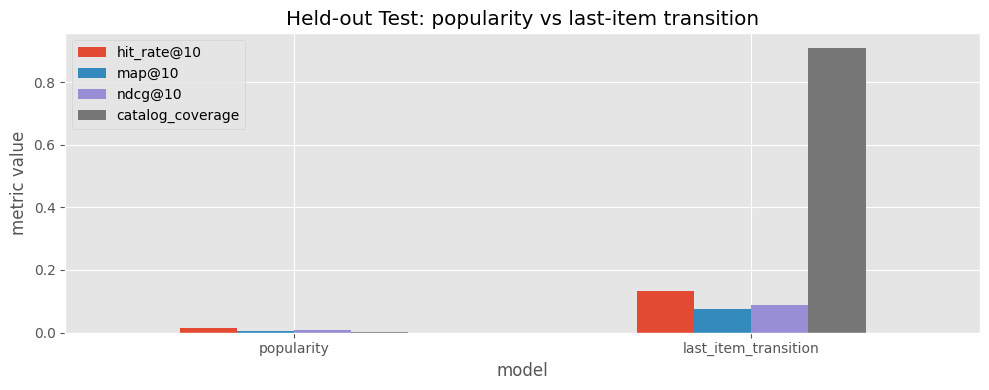

In [10]:
plot_df = test_comparison.set_index("model")[["hit_rate@10", "map@10", "ndcg@10", "catalog_coverage"]]
ax = plot_df.plot(kind="bar", figsize=(10, 4), rot=0)
ax.set_title("Held-out Test: popularity vs last-item transition")
ax.set_ylabel("metric value")
plt.tight_layout()
plt.show()


## Как интерпретировать результат

`last_item_transition` уверенно обыгрывает `popularity` на validation и на held-out test. На test `hit_rate@10` растёт примерно с 0.016 до 0.134, `MAP@10` — с 0.005 до 0.074, `NDCG@10` — с 0.008 до 0.088.

Главный учебный вывод: порядок событий действительно несёт полезный сигнал. Даже очень простая модель, которая смотрит только на последний item, оказывается сильнее глобальной популярности.

Важно читать результат аккуратно:

- `popularity` рекомендует почти один и тот же top-10 всем пользователям, поэтому покрытие каталога около 0.2%;
- `last_item_transition` даёт разные рекомендации для разных последних items, поэтому покрытие около 91%;
- validation-метрики выше test-метрик, значит качество немного проседает на более позднем событии, но эффект последовательного сигнала сохраняется;
- датасет сильно доминируется событиями `view`, поэтому текущие метрики в первую очередь описывают next-view поведение, а не покупку;
- это ещё не GRU4Rec и не Transformer: модель не использует длинную историю, тип события, время между событиями и признаки товара.

В текущем виде notebook показывает правильную базовую идею sequence recommendations: перед сложной нейронной архитектурой нужно убедиться, что простая sequential baseline уже лучше неперсонализированной популярности.


## Что дальше

Sequence-aware ветка показывает ещё один тип рекомендательной модели: здесь важен порядок событий пользователя.

Дальше мы возвращаемся к линии `retrieval -> ranking` и разбираем следующий системный слой: что происходит после candidate generation, если shortlist уже найден и его нужно переупорядочить более точным score.

Следующий шаг в маршруте: [05_retrieval_vs_ranking_toy.ipynb](05_retrieval_vs_ranking_toy.ipynb).
